<a href="https://colab.research.google.com/github/rhmau1/PCVK_26/blob/main/Modul6/Modul6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Mounted at /content/drive


In [4]:
def convolution2d(image, kernel, stride=1, padding=0):
  # Pastikan citra masukan berupa NumPy array
  image = np.array(image, dtype=float)
  kernel = np.array(kernel, dtype=float)

  # Rotasi kernel 180 derajat untuk operasi konvolusi sesungguhnya
  kernel = np.flipud(np.fliplr(kernel))

  # Dimensi citra dan kernel
  img_height, img_width = image.shape[:2]
  kernel_height, kernel_width = kernel.shape[:2]

  # Menambahkan padding (zero padding) jika dispesifikasikan
  if padding > 0:
    padded_image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
  else:
    padded_image = image

  # Dimensi citra setelah padding
  padded_height, padded_width = padded_image.shape[:2]

  # Menghitung dimensi output
  out_height = int((padded_height - kernel_height) / stride) + 1
  out_width = int((padded_width - kernel_width) / stride) + 1

  # Inisialisasi output image
  output = np.zeros((out_height, out_width))

  # Melakukan operasi konvolusi
  for y in range(0, out_height):
    for x in range(0, out_width):
      # Mengambil region of interest (ROI)
      y_start = y * stride
      y_end = y_start + kernel_height
      x_start = x * stride
      x_end = x_start + kernel_width

      roi = padded_image[y_start:y_end, x_start:x_end]

      # Element-wise multiplication dan penjumlahan
      output[y, x] = np.sum(roi * kernel)

  return output

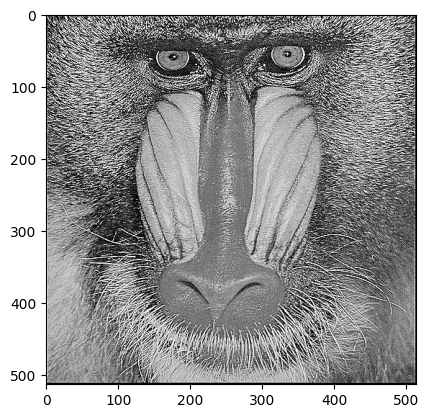

In [5]:
img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# kernel sharpening
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_sharpen_uint8 = np.clip(hasil_sharpen, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_sharpen_uint8, cv.COLOR_GRAY2RGB))
plt.show()

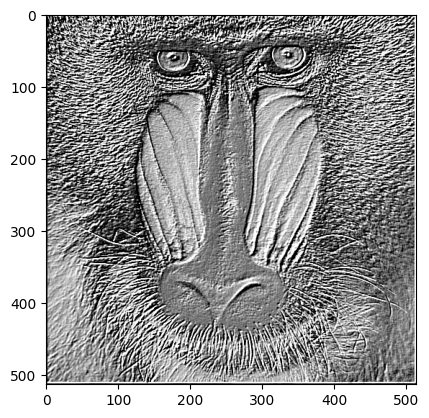

In [6]:

# kernel emboss
kernel_emboss = np.array([[-2,-1,0],
                           [-1,1,1],
                           [0,1,2]])
hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_emboss_uint8 = np.clip(hasil_emboss, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_emboss_uint8, cv.COLOR_GRAY2RGB))
plt.show()

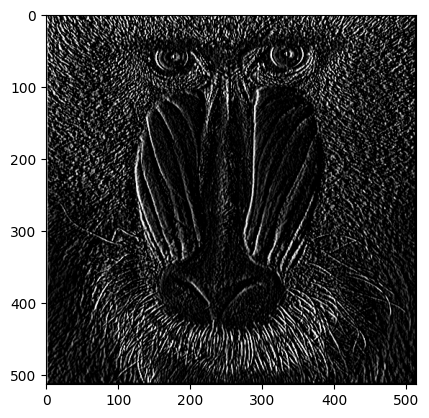

In [7]:

# kernel LeftSobelEdge
kernel_LeftSobelEdge = np.array([[1,0,-1],
                           [2,0,-2],
                           [1,0,-1]])
hasil_LeftSobelEdge = convolution2d(img_gray, kernel_LeftSobelEdge, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_LeftSobelEdge_uint8 = np.clip(hasil_LeftSobelEdge, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_LeftSobelEdge_uint8, cv.COLOR_GRAY2RGB))
plt.show()

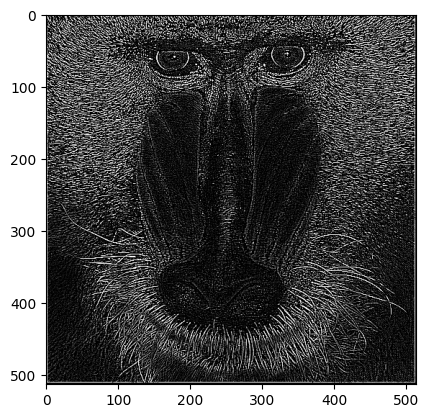

In [8]:

# kernel CannyEdge
kernel_CannyEdge = np.array([[-1,-1,-1],
                           [-1,8,-1],
                           [-1,-1,-1]])
hasil_CannyEdge = convolution2d(img_gray, kernel_CannyEdge, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_CannyEdge_uint8 = np.clip(hasil_CannyEdge, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_CannyEdge_uint8, cv.COLOR_GRAY2RGB))
plt.show()

In [9]:
kernel_size = 21

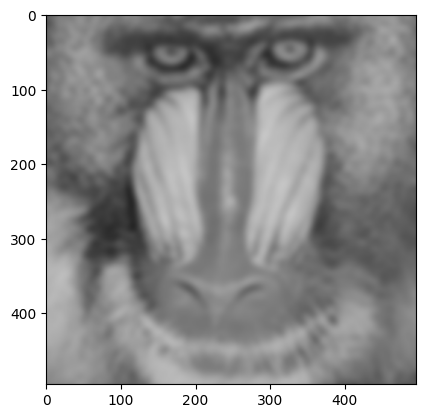

In [10]:
# gaussian kernel
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
kernel_gauss = gaussian_kernel @ gaussian_kernel.transpose()

hasil_gauss = convolution2d(img_gray, kernel_gauss, 1, 2)

# Convert the output to uint8 by clipping values to [0, 255]
hasil_gauss_uint8 = np.clip(hasil_gauss, 0, 255).astype(np.uint8)

plt.imshow(cv.cvtColor(hasil_gauss_uint8, cv.COLOR_GRAY2RGB))
plt.show()

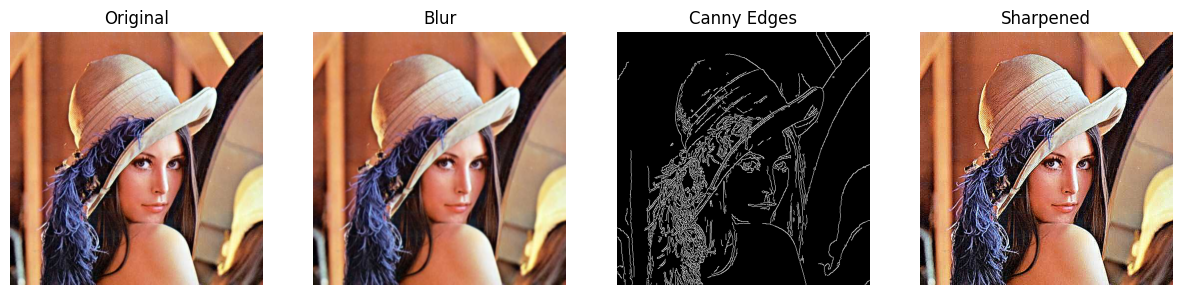

In [11]:
# fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    if len(img.shape) == 2: #grayscale
      plt.subplot(1, len(images), i+1)
      plt.imshow(img, cmap='gray')
    else:
      plt.subplot(1, len(images), i+1)
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
  plt.show()

img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0], [-1,5, -1], [0,-1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, edges, sharpened], ['Original', 'Blur', 'Canny Edges', 'Sharpened'])

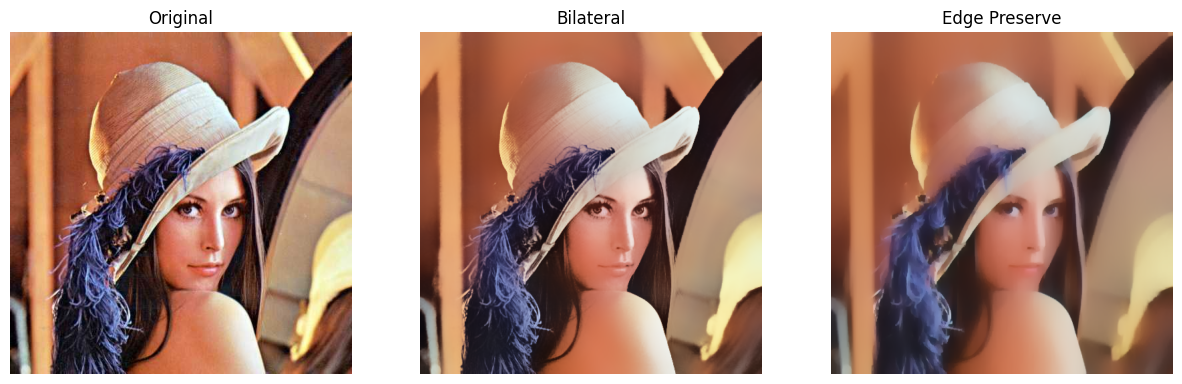

In [12]:
# filter modern dari open cv
# bilateral filter edge preserving
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# edge preserving filter (alternatif guided filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve], ['Original', 'Bilateral', 'Edge Preserve'])

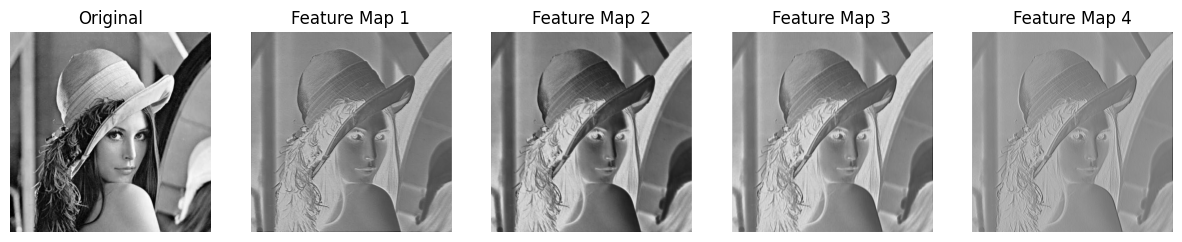

In [13]:
# filter feature map yg digunakan di CNN
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    def forward(self, x):
      return self.conv1(x)

model = SimpleCNN()

# ubahb gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0)/255.0

# hasil CNN
with torch.no_grad():
  features = model(img_tensor)

# visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ['Original'] + [f'Feature Map {i+1}' for i in range(len(feature_maps))])

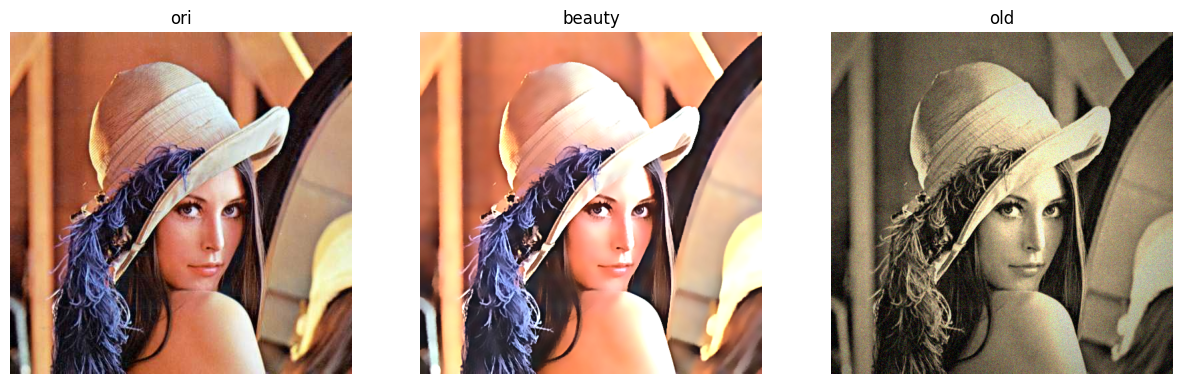

In [14]:
# beauty filter
# step 1 smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# step 2 unsharp masking pertajam mata/bibir
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# step 3 brightness dan contrast
alpha = 1.2
beta = 15
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# old / vintage filter
# step 1 sephia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# step 2 Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
  vignette[:,:,i] = vignette[:,:,i]*mask

# step 3 noise/grain
noise = np.random.normal(0,15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16)+noise, 0, 255).astype(np.uint8)
show_side_by_side([img, beauty, old_img], ['ori', 'beauty', 'old'])

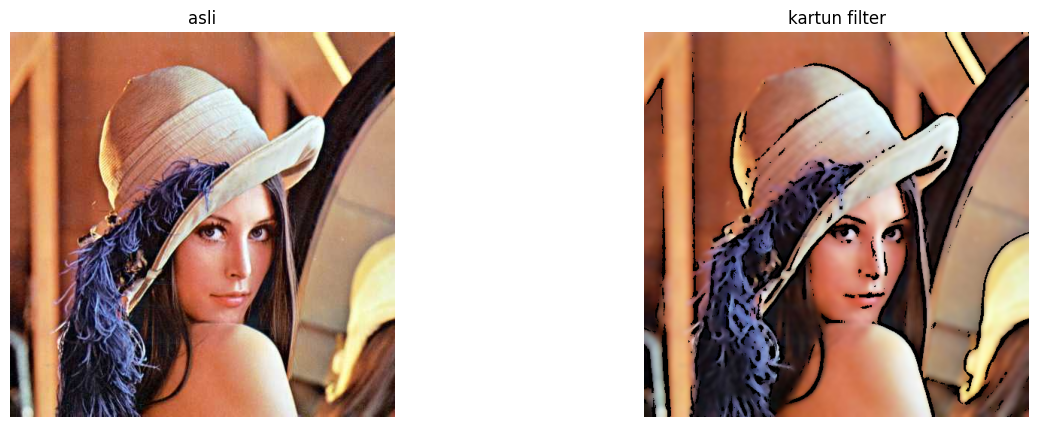

In [15]:
# filter anime cartoon
# step 1 edge detection pakai medium blur agar gambar menjadi halus
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9,9)

# step 2 bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor = 200, sigmaSpace=200)
# step3 gabungkan cartoonize
cartoon = cv.bitwise_and(color, color, mask=edges)

# tampilkan
show_side_by_side([img, cartoon], ['asli', 'kartun filter'])

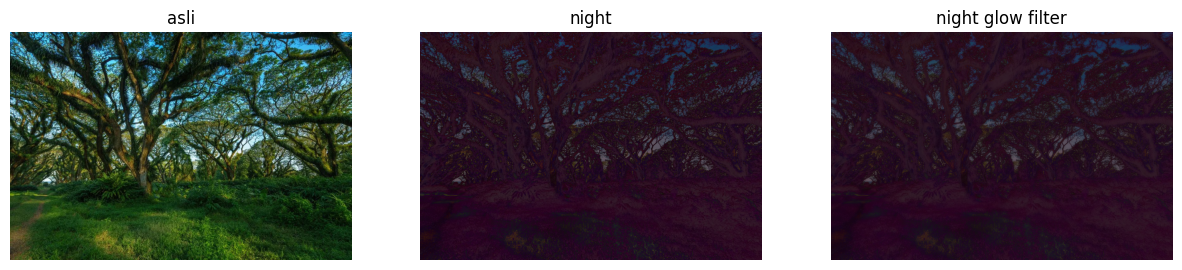

In [16]:
# night filter
img = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/djawatan.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# step 1 gelapkan constrast turun brightness negatif
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)
# tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) #BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# step 3 efek glow di area terang dengan filter2d blur kernel
kernel = np.ones((15,15), np.float32) /225
glow = cv.filter2D(night, -1, kernel)

# kombinasikan asli +glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)
show_side_by_side([img, night, night_glow], ['asli', 'night','night glow filter'])

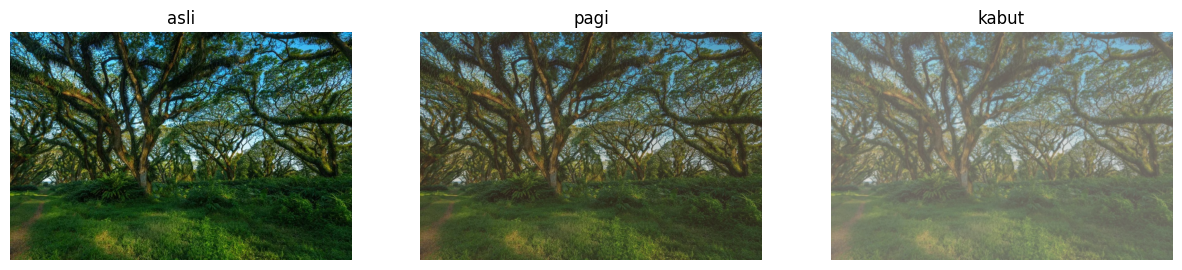

In [17]:
# filter suasana pagi dan kabut
# step 1 kurangi kontras dan cerahkan
alpha = 0.9 #contrast
beta =20 #brightness
soft = cv.convertScaleAbs(img, alpha = alpha, beta=beta)
# step 2 tambahkan warm tone kemerahan atau orange
warm_tint = np.full_like(soft, (40,70,120))
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# step 3 tambahakn haze kabut tipis dengan filter 2d
# kernel blur gaussian like untuk efek kabut
kernel = cv.getGaussianKernel(3,3)
kernel = kernel @ kernel.T
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk layer kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut], ['asli', 'pagi', 'kabut'])

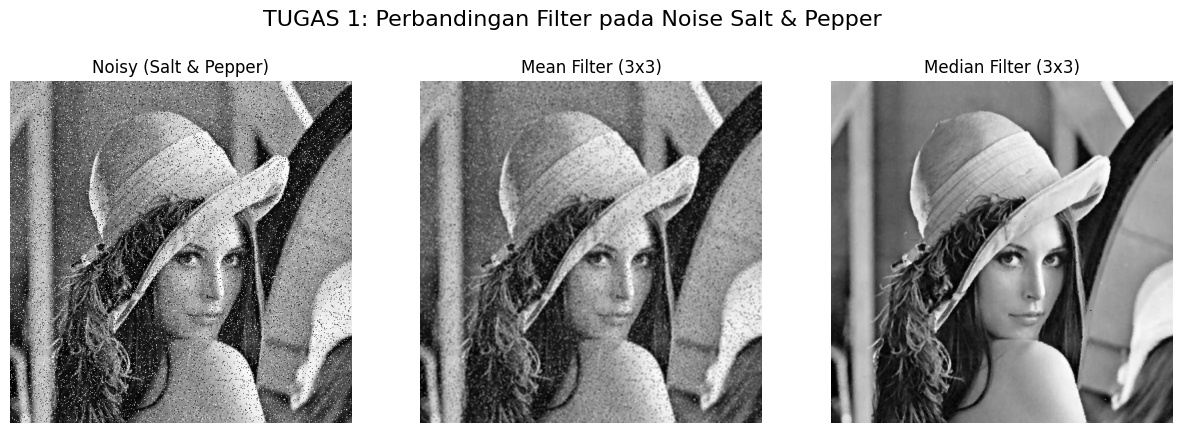

Analisis Tugas 1:
Median Filter jauh lebih bersih dalam menghapus noise Salt and Pepper dibanding Mean Filter karena:
- Mean Filter menggantikan nilai piksel dengan rata-rata tetangganya. Akibatnya, nilai ekstrem (0 atau 255 dari noise) ikut dihitung dalam rata-rata sehingga noise tersebar menjadi kabur abu-abu (tidak hilang sepenuhnya).
- Median Filter menggantikan piksel dengan nilai tengah (median) setelah diurutkan. Karena noise Salt and Pepper merupakan nilai ekstrem (sangat tinggi/rendah), nilai ini akan selalu berada di ujung daftar urutan dan tidak pernah terpilih sebagai nilai median. Sehingga noise berhasil dihilangkan secara sempurna tanpa merusak ketajaman tepi secara drastis.
--------------------------------------------------------------------------------


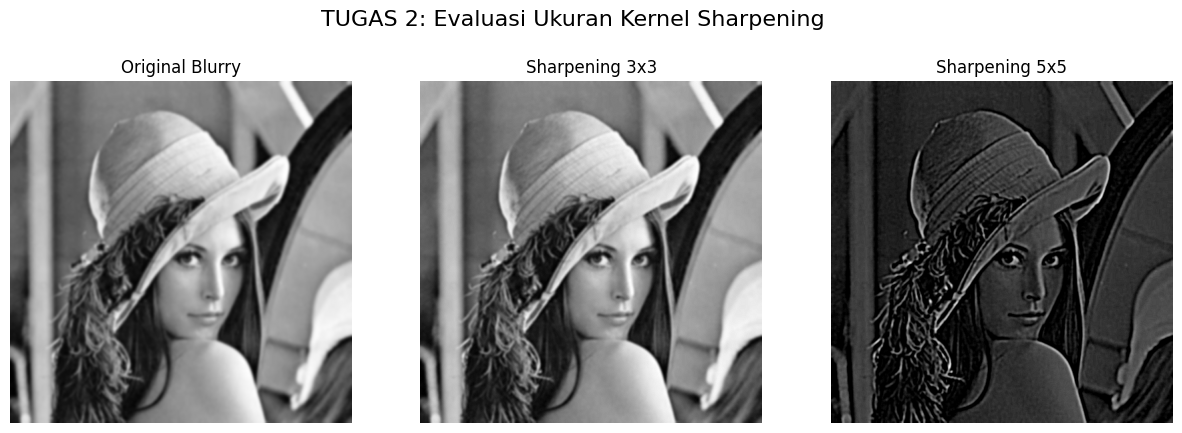

Analisis Tugas 2:
- Kernel 3x3 memberikan penajaman yang halus dan tampak natural. Tepi objek menjadi lebih jelas dengan noise distortion yang minimal.
- Kernel 5x5 menghasilkan penajaman yang sangat kuat pada tepi, namun memiliki kelemahan merusak detail halus dan memperbesar (mengamplifikasi) noise atau distorsi frekuensi tinggi di area yang datar.

Kesimpulan Optimalitas:
Untuk penggunaan sehari-hari, kernel 3x3 jauh lebih optimal karena memberikan keseimbangan terbaik antara peningkatan kejelasan tepi (edge clarity) tanpa memicu noise distortion yang mengganggu.
--------------------------------------------------------------------------------


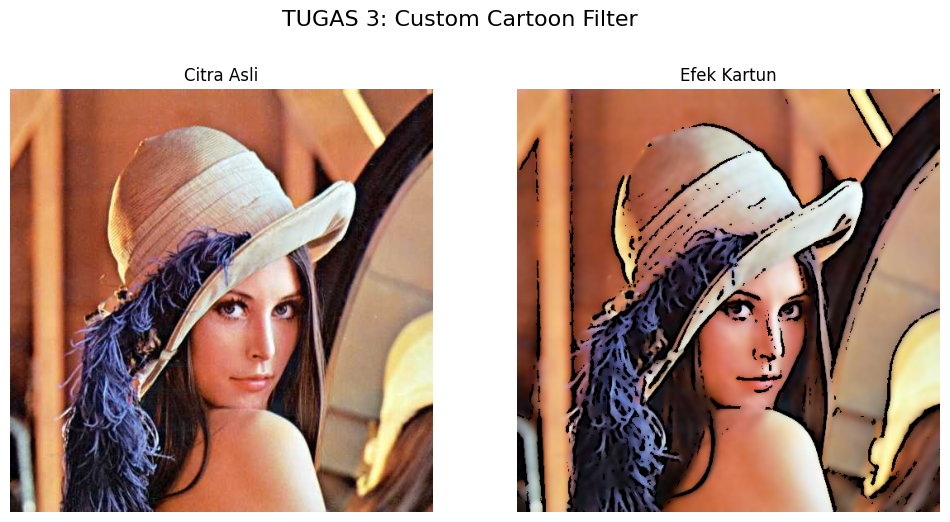

In [18]:
# ==========================================
# TUGAS 1: Mean Filter vs Median Filter pada Noise "Salt and Pepper"
# ==========================================

# Fungsi menambahkan noise Salt & Pepper
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = np.copy(image)
    # Salt noise (piksel putih)
    num_salt = np.ceil(salt_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords)] = 255

    # Pepper noise (piksel hitam)
    num_pepper = np.ceil(pepper_prob * image.size)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords)] = 0
    return noisy_image

# Menggunakan citra grayscale dari lena
img_target = cv.imread('/content/drive/MyDrive/TI 3C RESOURCES /PCVK/Images/lena.jpg')
if img_target is None:
    # fallback jika file tidak ditemukan
    img_gray_target = img_gray
else:
    img_gray_target = cv.cvtColor(img_target, cv.COLOR_BGR2GRAY)

# Tambahkan noise
noisy_img = add_salt_and_pepper_noise(img_gray_target, 0.05, 0.05)

# Terapkan Mean Filter 3x3 dan Median Filter 3x3
mean_filtered = cv.blur(noisy_img, (3, 3))
median_filtered = cv.medianBlur(noisy_img, 3)

# Tampilkan Hasil Tugas 1
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(noisy_img, cmap='gray')
plt.title('Noisy (Salt & Pepper)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mean_filtered, cmap='gray')
plt.title('Mean Filter (3x3)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filter (3x3)')
plt.axis('off')
plt.suptitle("TUGAS 1: Perbandingan Filter pada Noise Salt & Pepper", fontsize=16)
plt.show()

print("""Analisis Tugas 1:
Median Filter jauh lebih bersih dalam menghapus noise Salt and Pepper dibanding Mean Filter karena:
- Mean Filter menggantikan nilai piksel dengan rata-rata tetangganya. Akibatnya, nilai ekstrem (0 atau 255 dari noise) ikut dihitung dalam rata-rata sehingga noise tersebar menjadi kabur abu-abu (tidak hilang sepenuhnya).
- Median Filter menggantikan piksel dengan nilai tengah (median) setelah diurutkan. Karena noise Salt and Pepper merupakan nilai ekstrem (sangat tinggi/rendah), nilai ini akan selalu berada di ujung daftar urutan dan tidak pernah terpilih sebagai nilai median. Sehingga noise berhasil dihilangkan secara sempurna tanpa merusak ketajaman tepi secara drastis.""")
print("-"*80)

# ==========================================
# TUGAS 2: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)
# ==========================================

# Buat citra buram artifisial terlebih dahulu
blurry_img = cv.GaussianBlur(img_gray_target, (9, 9), 0)

# Kernel Sharpening 3x3
kernel_sharp_3x3 = np.array([[0, -1, 0],
                             [-1, 5, -1],
                             [0, -1, 0]])

# Kernel Sharpening 5x5 (pusat ditinggikan, sekeliling negatif untuk efek penajaman lebih kuat)
kernel_sharp_5x5 = np.array([[-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, 25, -1, -1],
                             [-1, -1, -1, -1, -1],
                             [-1, -1, -1, -1, -1]]) / 9.0

# Terapkan filter
sharp_3x3 = cv.filter2D(blurry_img, -1, kernel_sharp_3x3)
sharp_5x5 = cv.filter2D(blurry_img, -1, kernel_sharp_5x5)

# Tampilkan Hasil Tugas 2
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(blurry_img, cmap='gray')
plt.title('Original Blurry')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharp_3x3, cmap='gray')
plt.title('Sharpening 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharp_5x5, cmap='gray')
plt.title('Sharpening 5x5')
plt.axis('off')
plt.suptitle("TUGAS 2: Evaluasi Ukuran Kernel Sharpening", fontsize=16)
plt.show()

print("""Analisis Tugas 2:
- Kernel 3x3 memberikan penajaman yang halus dan tampak natural. Tepi objek menjadi lebih jelas dengan noise distortion yang minimal.
- Kernel 5x5 menghasilkan penajaman yang sangat kuat pada tepi, namun memiliki kelemahan merusak detail halus dan memperbesar (mengamplifikasi) noise atau distorsi frekuensi tinggi di area yang datar.

Kesimpulan Optimalitas:
Untuk penggunaan sehari-hari, kernel 3x3 jauh lebih optimal karena memberikan keseimbangan terbaik antara peningkatan kejelasan tepi (edge clarity) tanpa memicu noise distortion yang mengganggu.""")
print("-"*80)

# ==========================================
# TUGAS 3: Filter Kartun Sederhana
# ==========================================

def kartun(image):
    # 1. Penghalusan warna menggunakan Bilateral Filter
    color_smooth = cv.bilateralFilter(image, d=9, sigmaColor=150, sigmaSpace=150)

    # 2. Deteksi garis tepi menggunakan Adaptive Thresholding
    gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray_img, 5)
    edges_mask = cv.adaptiveThreshold(gray_blur, 255,
                                      cv.ADAPTIVE_THRESH_MEAN_C,
                                      cv.THRESH_BINARY, 9, 9)

    # 3. Penggabungan menggunakan operasi AND logika bitwise
    cartoon_result = cv.bitwise_and(color_smooth, color_smooth, mask=edges_mask)
    return cartoon_result

# Jalankan fungsi kartun
img_color_source = img_target if img_target is not None else img
img_cartoon = kartun(img_color_source)

# Tampilkan Hasil Tugas 3
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img_color_source, cv.COLOR_BGR2RGB))

plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(img_cartoon, cv.COLOR_BGR2RGB))
plt.title('Efek Kartun')
plt.axis('off')
plt.suptitle("TUGAS 3: Custom Cartoon Filter", fontsize=16)
plt.show()
